# Compressibility

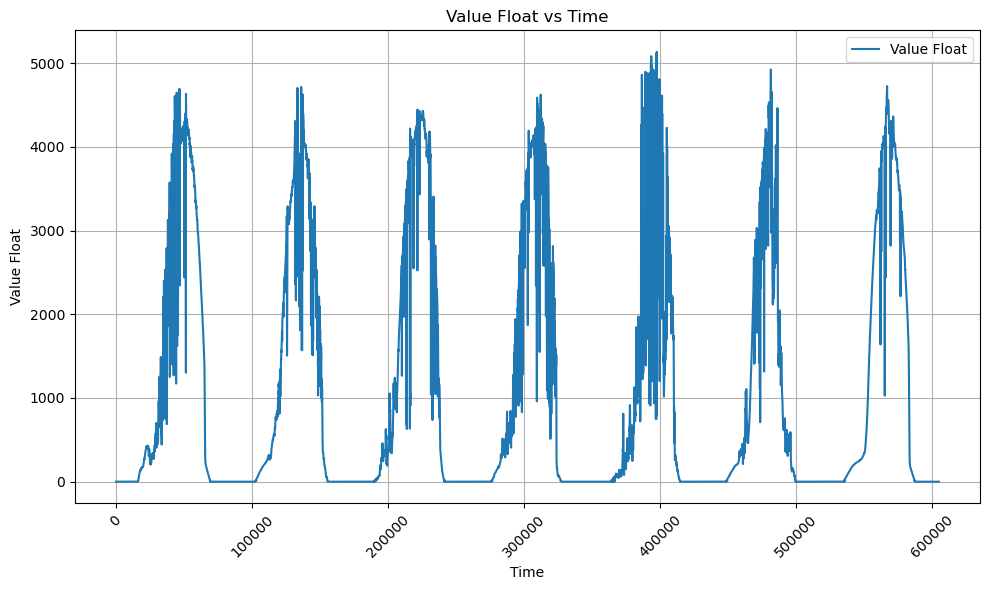

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming you have a dataframe 'df' with 'time' and 'value_float' columns
df = pd.read_pickle("All dataframes/dataframes-full-set/PV_Inverter_Active_Power.pkl")
# Convert 'time' to ISO 8601 strings
# Convert 'time' to datetime if it's not already

df['time'] = pd.to_datetime(df['time'])
Time = pd.to_datetime(df['time'])
time_numeric = (Time - Time.iloc[0]).dt.total_seconds().astype(int)
# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(time_numeric, df['value_float'], label='Value Float')

plt.title('Value Float vs Time')
plt.xlabel('Time')
plt.ylabel('Value Float')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.grid(True)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [4]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt


# Constants
R = 8.314  # Universal gas constant [J/(mol·K)]
T = 298    # Temperature [K]
P = 270e5  # Pressure [Pa]
V = (50*53) / 1000  # Volume [m³]
M = 2.016           # molar mass of hydrogen [g/mol]


a = 0.2476 / (1000**2)  # [Pa·m^6/mol^2]
b = 0.0266 / 1000       # [m³/mol]

# Ideal Gas Law
n = (P*V)/(R*T)         # [mol]
m = n*M/1000            # mass [kg]

# Van der Waals Equation
def vdw(n):
    return (P+(a/n**2))*(V-n*b) - n*R*T

# We solve for n, the number of moles, using the fsolve:
n2 = fsolve(vdw, n)[0] # [mol] we guess the ideal situation
m2 = n2*M/1000         # Convert mol to mass [kg]

# Results
print(f"Ideal Gas Law:")
print(f"Moles of H2: {n:.4f} [mol]")
print(f"Mass of H2: {m:.4f} [kg]")
print()
print(f"Non-Ideal Gas (Van der Waals):")
print(f"Moles of H2: {n2:.4f} [mol]")
print(f"Mass of H2: {m2:.4f} [kg]")


Ideal Gas Law:
Moles of H2: 28879.0800 [mol]
Mass of H2: 58.2202 [kg]

Non-Ideal Gas (Van der Waals):
Moles of H2: 22388.9564 [mol]
Mass of H2: 45.1361 [kg]


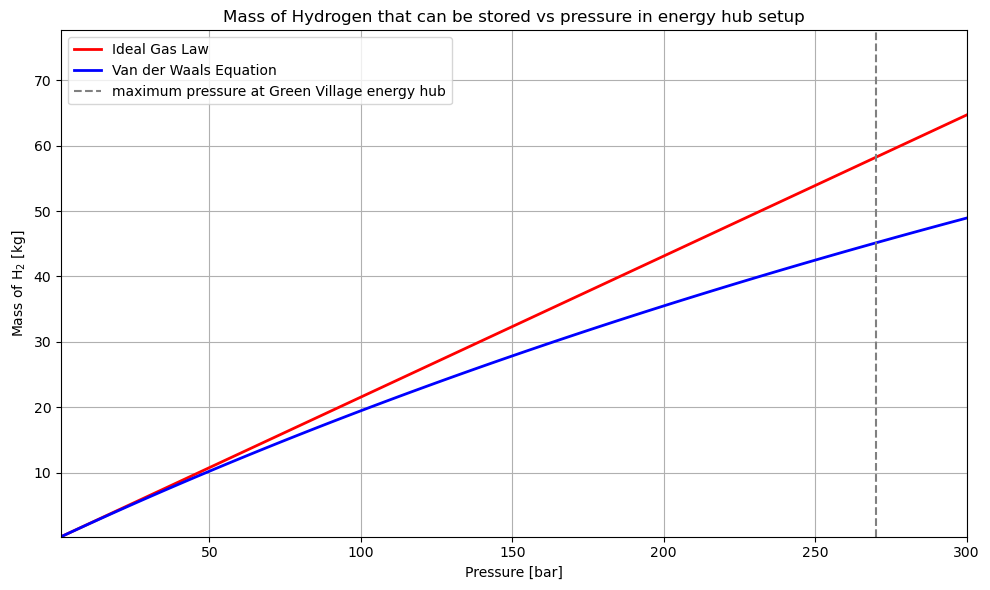

In [6]:

# Van der Waals Equation that also takes pressure, volume and temperature
def vdw(n, P, V, T):
    return (P+(a/n**2))*(V-n*b) - n*R*T


# Pressure range (in Pa), we test from 1 to 300 bar
pressures = np.linspace(1e5, 300e5, 100)


masses = []
masses2 = []

# Calculate mass for each pressure
for P in pressures:
    # Ideal Gas Law,
    n = (P*V)/(R*T)
    m = (n*M)/1000 # store mass for ideal situation
    masses.append(m)

    # Van der Waals
    n2 = fsolve(vdw, n, args=(P,V,T))[0]
    m2 = (n2*M)/1000 # store mass for vdw
    masses2.append(m2)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(pressures / 1e5, masses, label="Ideal Gas Law", linestyle='-', linewidth = 2, color='red')
plt.plot(pressures / 1e5, masses2, label="Van der Waals Equation", linestyle='-', linewidth = 2, color='blue')
plt.axvline(270, linestyle='--', color = 'grey', label="maximum pressure at Green Village energy hub")
plt.xlabel("Pressure [bar]")
plt.xlim(min(pressures/100000), max(pressures/100000))
plt.ylabel("Mass of H$_2$ [kg]")
plt.ylim(min(masses), max(masses)*1.2)
plt.title("Mass of Hydrogen that can be stored vs pressure in energy hub setup")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Compressibility.PNG")
# Show the plot
plt.show()

In [8]:
closest_index = np.abs((pressures / 1e5) - 270).argmin()

# Retrieve the masses for the corresponding pressure
mass1 = masses[closest_index]
mass2 = masses2[closest_index]

print(mass1)
print(mass2)

58.17666357517469
45.109949530017914


In [10]:
# Compression energy:
P1 = 3500000 # [Pa]
P2 = 27000000 # [Pa]
V2 = 50*53/1000 # [m3]
E = -P2*V2*np.log(P1/P2)

print(f"Energy required to comrpess all gas: {E:.2f} [J]")
print(f"Energy required to comrpess all gas: {E/3600000:.2f} [kWh]")

Energy required to comrpess all gas: 146181937.37 [J]
Energy required to comrpess all gas: 40.61 [kWh]
